In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU. Inference will work, just be a few seconds slower.")

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers torchaudio

In [ ]:
# Option A: Upload directly from your computer
from google.colab import files
print("Click 'Choose Files' and select finetune_best.pt")
uploaded = files.upload()

# Move it to a predictable location
import os, shutil
os.makedirs("checkpoints", exist_ok=True)
for filename in uploaded.keys():
    shutil.move(filename, f"checkpoints/{filename}")
    print(f"Saved to checkpoints/{filename}")

Click 'Choose Files' and select finetune_best.pt


Saving finetune_best.pt to finetune_best.pt
Saved to checkpoints/finetune_best.pt


In [ ]:
import torch

# ── Model ───────────────────────────────────────────────────
PRETRAINED_MODEL = "facebook/wav2vec2-base"
HIDDEN_DIM       = 768
NUM_CLASSES      = 8

# ── Audio ───────────────────────────────────────────────────
SAMPLE_RATE       = 16000
MAX_AUDIO_SECONDS = 4.0
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * MAX_AUDIO_SECONDS)

# ── Device ──────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Emotion labels (must match training order) ──────────────
EMOTION_MAP = {
    "01": "neutral",  "02": "calm",     "03": "happy",   "04": "sad",
    "05": "angry",    "06": "fearful",  "07": "disgust", "08": "surprised",
}
EMOTION_TO_IDX = {name: idx for idx, name in enumerate(sorted(EMOTION_MAP.values()))}
IDX_TO_EMOTION = {idx: name for name, idx in EMOTION_TO_IDX.items()}

CHECKPOINT_PATH = "checkpoints/finetune_best.pt"

print(f"Device: {DEVICE}")
print(f"Will load checkpoint from: {CHECKPOINT_PATH}")

Device: cuda
Will load checkpoint from: checkpoints/finetune_best.pt


In [ ]:
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor


class EmotionClassifierHead(nn.Module):
    def __init__(self, input_dim=HIDDEN_DIM, hidden_dim=256,
                 num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def masked_mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (hidden_states * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-6)
    return summed / counts


class Wav2Vec2EmotionModel(nn.Module):
    def __init__(self, pretrained_model_name=PRETRAINED_MODEL, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = Wav2Vec2Model.from_pretrained(pretrained_model_name)
        self.encoder.feature_extractor._freeze_parameters()
        self.head = EmotionClassifierHead(
            input_dim=self.encoder.config.hidden_size,
            num_classes=num_classes,
        )

    def forward(self, input_values, attention_mask=None):
        outputs = self.encoder(input_values=input_values, attention_mask=attention_mask)
        if attention_mask is not None:
            input_lengths = attention_mask.sum(dim=1)
            output_lengths = self.encoder._get_feat_extract_output_lengths(input_lengths).to(torch.long)
            B, T_out, _ = outputs.last_hidden_state.shape
            output_mask = torch.zeros((B, T_out), dtype=torch.long,
                                      device=outputs.last_hidden_state.device)
            for i, length in enumerate(output_lengths):
                output_mask[i, :length] = 1
            pooled = masked_mean_pool(outputs.last_hidden_state, output_mask)
        else:
            pooled = outputs.last_hidden_state.mean(dim=1)
        return self.head(pooled)


print("Model architecture defined.")

Model architecture defined.


In [ ]:
import os

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"No checkpoint found at {CHECKPOINT_PATH}. "
        "Did you upload finetune_best.pt in section 3?"
    )

print(f"Loading model architecture and {CHECKPOINT_PATH}...")
model = Wav2Vec2EmotionModel().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

# Also load the feature extractor (handles audio normalization)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED_MODEL)

print("Model loaded and ready for inference!")

Loading model architecture and checkpoints/finetune_best.pt...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

Model loaded and ready for inference!


In [ ]:
import subprocess
import torchaudio


def load_and_preprocess_audio(path: str) -> torch.Tensor:
    """Load any audio file, convert to mono 16kHz, fixed length."""
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.transforms.Resample(sr, SAMPLE_RATE)(waveform)
    waveform = waveform.squeeze(0)
    if waveform.size(0) < MAX_AUDIO_SAMPLES:
        waveform = torch.nn.functional.pad(
            waveform, (0, MAX_AUDIO_SAMPLES - waveform.size(0))
        )
    else:
        waveform = waveform[:MAX_AUDIO_SAMPLES]
    return waveform


def convert_to_wav_if_needed(input_path: str) -> str:
    """If the file isn't a .wav, convert it using ffmpeg. Returns the path to use."""
    if input_path.lower().endswith(".wav"):
        return input_path
    output_path = "_temp_converted.wav"
    subprocess.run([
        "ffmpeg", "-y", "-i", input_path,
        "-ac", "1", "-ar", str(SAMPLE_RATE), output_path,
    ], check=True, capture_output=True)
    return output_path


print("Audio utilities ready.")

Audio utilities ready.


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def predict_emotion(audio_path: str, show_plot: bool = True):
    """
    Predict the emotion of an audio recording.

    Args:
        audio_path: path to an audio file (.m4a, .wav, .mp3, etc.)
        show_plot: if True, display a bar chart of probabilities

    Returns:
        (predicted_emotion, confidence, probs_dict)
    """
    # Convert if needed (m4a, mp3, etc.) and load
    wav_path = convert_to_wav_if_needed(audio_path)
    waveform = load_and_preprocess_audio(wav_path)

    # Run through the model
    with torch.no_grad():
        inputs = feature_extractor(
            waveform.numpy(),
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            return_attention_mask=True,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        logits = model(**inputs)
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    # Format the results
    predicted_idx = int(probs.argmax())
    predicted_emotion = IDX_TO_EMOTION[predicted_idx]
    confidence = float(probs[predicted_idx])
    probs_dict = {IDX_TO_EMOTION[i]: float(probs[i]) for i in range(len(probs))}

    # Print a nice summary
    print(f"\n{'='*50}")
    print(f"  File: {audio_path}")
    print(f"  Predicted: {predicted_emotion.upper()} ({confidence*100:.1f}%)")
    print(f"{'='*50}")
    sorted_indices = probs.argsort()[::-1]
    for idx in sorted_indices:
        emotion = IDX_TO_EMOTION[idx]
        bar = "█" * int(probs[idx] * 40)
        marker = "→" if idx == predicted_idx else " "
        print(f"  {marker} {emotion:>10s}: {probs[idx]*100:5.1f}%  {bar}")

    # Plot
    if show_plot:
        emotions = [IDX_TO_EMOTION[i] for i in sorted(IDX_TO_EMOTION.keys())]
        plt.figure(figsize=(10, 3.5))
        colors = ['#2ecc71' if i == predicted_idx else '#3498db'
                  for i in range(len(emotions))]
        plt.bar(emotions, probs * 100, color=colors)
        plt.ylabel("Probability (%)")
        plt.title(f"Emotion: {predicted_emotion.upper()}  ({audio_path})")
        plt.xticks(rotation=45)
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.show()

    return predicted_emotion, confidence, probs_dict


print("Ready to predict! Use: predict_emotion('your_file.m4a')")

Ready to predict! Use: predict_emotion('your_file.m4a')


In [ ]:
from google.colab import files
print("Click 'Choose Files' and select your recording(s).")
uploaded_audio = files.upload()
for fname in uploaded_audio.keys():
    print(f"  Uploaded: {fname}")

Click 'Choose Files' and select your recording(s).


Saving Barbara.m4a to Barbara.m4a
Saving Crowd.m4a to Crowd.m4a
Saving football.m4a to football.m4a
Saving Hey buddy.m4a to Hey buddy.m4a
Saving kazuki-mad.m4a to kazuki-mad.m4a
Saving Roy.m4a to Roy.m4a
Saving Boss.m4a to Boss (1).m4a
Saving Dot.m4a to Dot (1).m4a
Saving Josh o Connor.m4a to Josh o Connor (1).m4a
Saving Kangana.m4a to Kangana (1).m4a
Saving M.m4a to M (1).m4a
Saving Srikant.m4a to Srikant (1).m4a
  Uploaded: Barbara.m4a
  Uploaded: Crowd.m4a
  Uploaded: football.m4a
  Uploaded: Hey buddy.m4a
  Uploaded: kazuki-mad.m4a
  Uploaded: Roy.m4a
  Uploaded: Boss (1).m4a
  Uploaded: Dot (1).m4a
  Uploaded: Josh o Connor (1).m4a
  Uploaded: Kangana (1).m4a
  Uploaded: M (1).m4a
  Uploaded: Srikant (1).m4a


## 10. Predict emotions on your recordings!

Edit the filenames below and run. You can call `predict_emotion()` as many times as you want.


  File: Srikant.m4a
  Predicted: CALM (97.3%)
  →       calm:  97.3%  ██████████████████████████████████████
       disgust:   1.9%  
           sad:   0.5%  
       neutral:   0.2%  
         angry:   0.0%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  


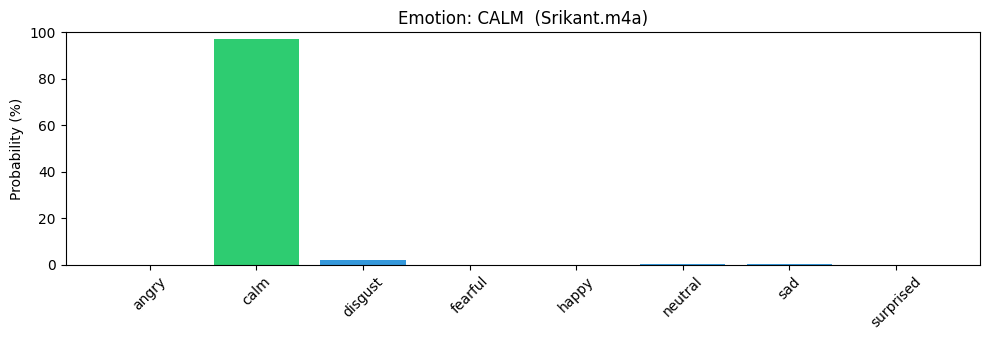

('calm',
 0.9734256267547607,
 {'angry': 0.00033191146212629974,
  'calm': 0.9734256267547607,
  'disgust': 0.018955135717988014,
  'fearful': 1.2291358871152624e-05,
  'happy': 9.778459934750572e-05,
  'neutral': 0.0023097312077879906,
  'sad': 0.004833395592868328,
  'surprised': 3.421851579332724e-05})

In [ ]:
# Replace with whatever you uploaded
predict_emotion("Srikant.m4a")

### Predict on multiple recordings at once

If you uploaded several files, you can loop through them:


  File: Barbara.m4a
  Predicted: CALM (97.5%)
  →       calm:  97.5%  ███████████████████████████████████████
           sad:   1.1%  
       disgust:   0.9%  
       neutral:   0.4%  
         angry:   0.0%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  


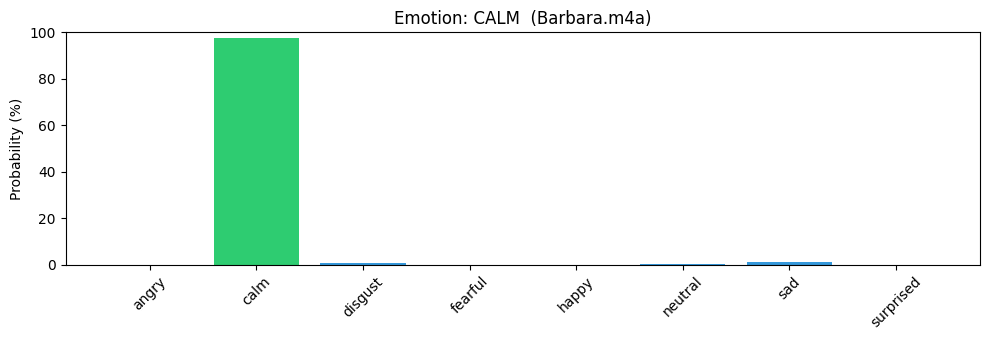


  File: Crowd.m4a
  Predicted: DISGUST (92.1%)
  →    disgust:  92.1%  ████████████████████████████████████
          calm:   3.1%  █
           sad:   1.8%  
         angry:   1.5%  
         happy:   0.5%  
       neutral:   0.5%  
     surprised:   0.3%  
       fearful:   0.2%  


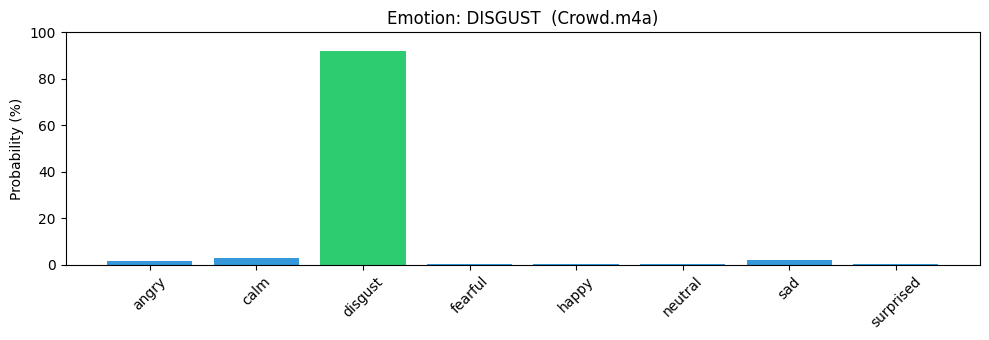


  File: football.m4a
  Predicted: CALM (95.6%)
  →       calm:  95.6%  ██████████████████████████████████████
       disgust:   2.9%  █
           sad:   1.3%  
       neutral:   0.1%  
         angry:   0.0%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  


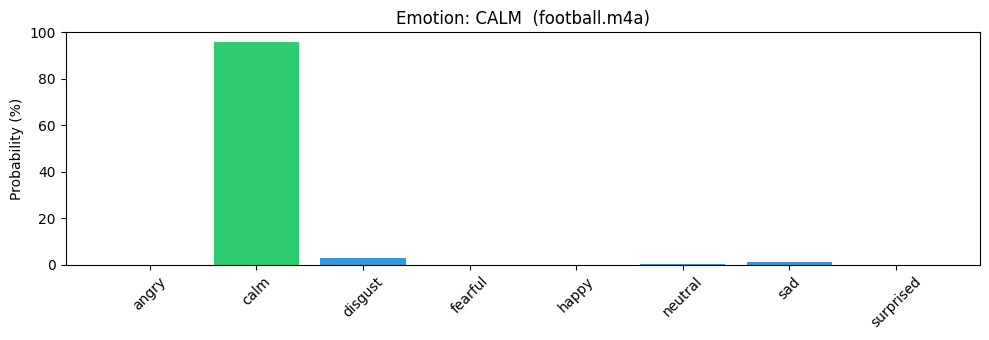


  File: Hey buddy.m4a
  Predicted: CALM (96.0%)
  →       calm:  96.0%  ██████████████████████████████████████
           sad:   1.8%  
       neutral:   1.7%  
       disgust:   0.4%  
         angry:   0.1%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  


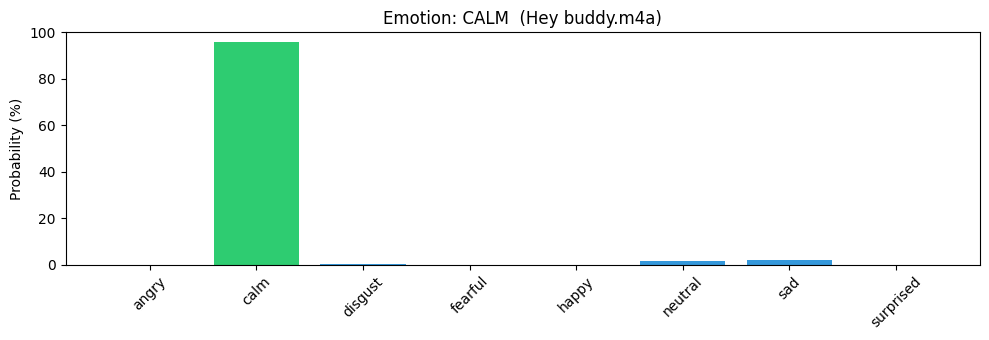


  File: kazuki-mad.m4a
  Predicted: SAD (99.8%)
  →        sad:  99.8%  ███████████████████████████████████████
          calm:   0.1%  
       fearful:   0.1%  
       disgust:   0.0%  
         happy:   0.0%  
       neutral:   0.0%  
     surprised:   0.0%  
         angry:   0.0%  


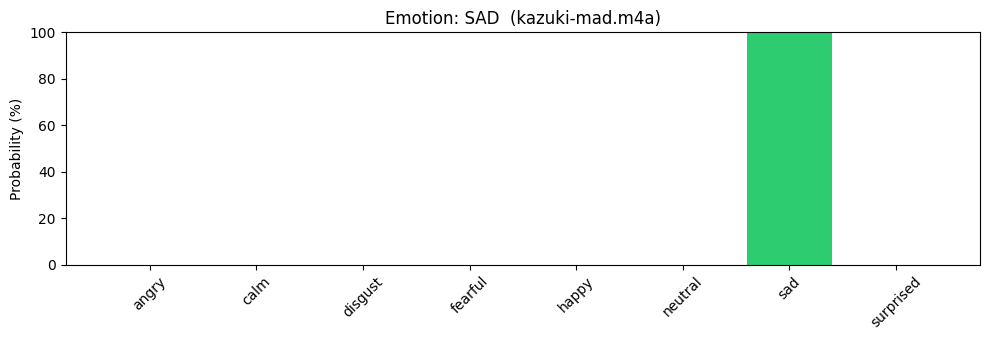


  File: Roy.m4a
  Predicted: CALM (96.3%)
  →       calm:  96.3%  ██████████████████████████████████████
       disgust:   1.6%  
           sad:   1.5%  
       neutral:   0.5%  
         angry:   0.1%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  


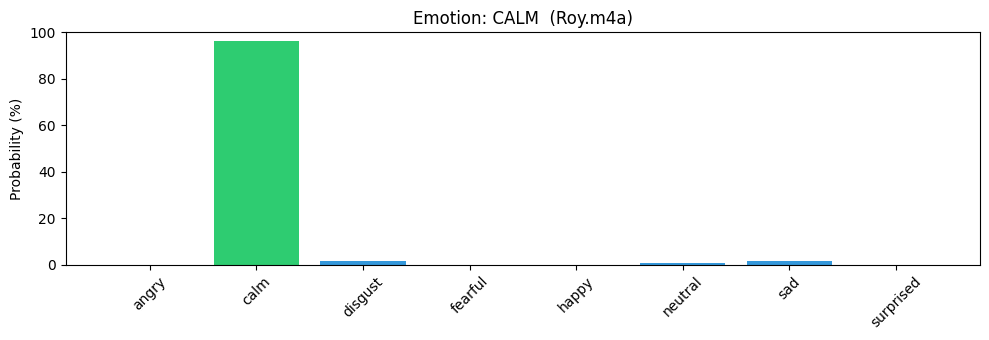


  File: Boss (1).m4a
  Predicted: CALM (67.3%)
  →       calm:  67.3%  ██████████████████████████
       disgust:  16.7%  ██████
           sad:  13.8%  █████
       neutral:   1.2%  
         happy:   0.4%  
         angry:   0.4%  
       fearful:   0.1%  
     surprised:   0.1%  


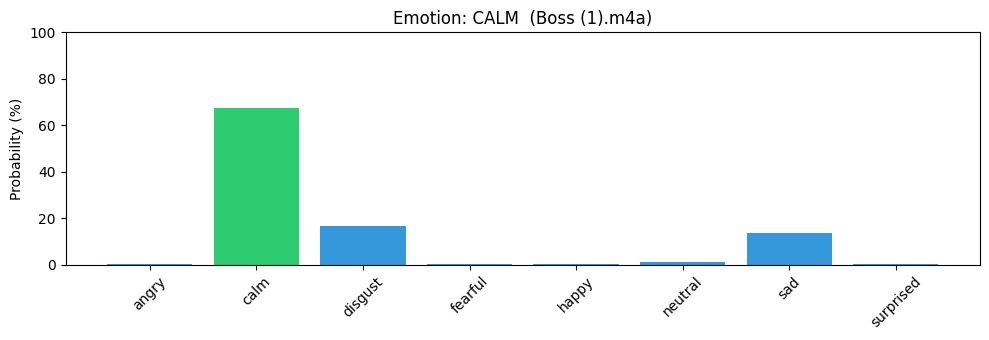


  File: Dot (1).m4a
  Predicted: FEARFUL (46.5%)
  →    fearful:  46.5%  ██████████████████
           sad:  34.2%  █████████████
       disgust:   6.0%  ██
         happy:   5.1%  ██
         angry:   4.2%  █
     surprised:   2.2%  
          calm:   1.1%  
       neutral:   0.8%  


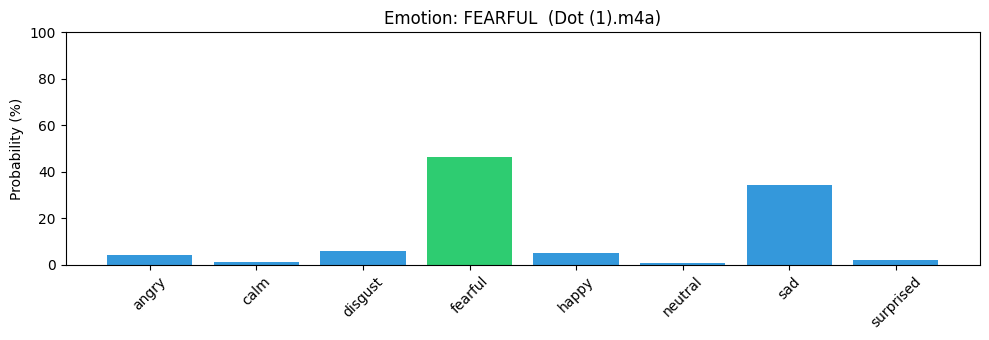


  File: Josh o Connor (1).m4a
  Predicted: DISGUST (82.1%)
  →    disgust:  82.1%  ████████████████████████████████
          calm:   9.0%  ███
           sad:   7.8%  ███
         angry:   0.5%  
         happy:   0.2%  
       neutral:   0.2%  
       fearful:   0.1%  
     surprised:   0.0%  


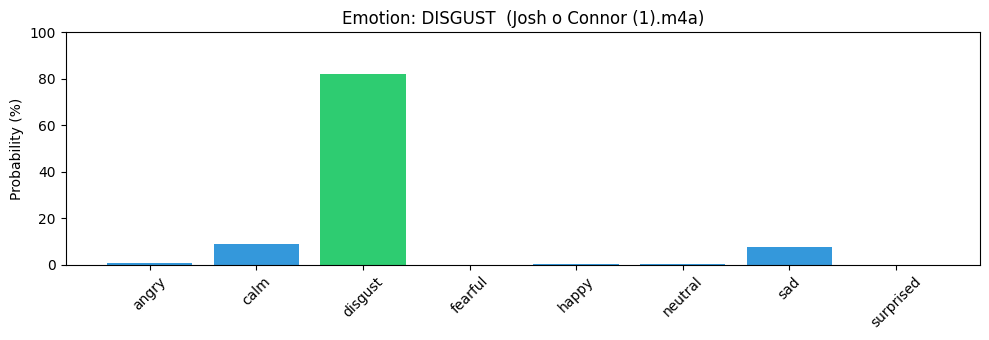


  File: Kangana (1).m4a
  Predicted: SAD (99.1%)
  →        sad:  99.1%  ███████████████████████████████████████
          calm:   0.5%  
       neutral:   0.1%  
         happy:   0.1%  
       disgust:   0.1%  
       fearful:   0.0%  
     surprised:   0.0%  
         angry:   0.0%  


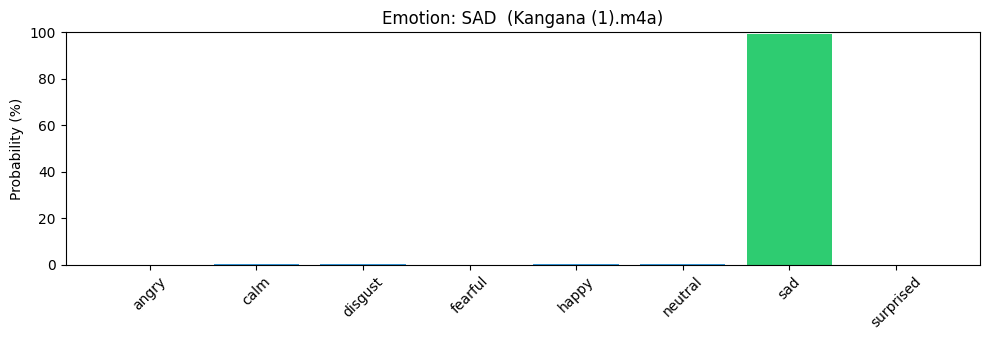


  File: M (1).m4a
  Predicted: DISGUST (99.5%)
  →    disgust:  99.5%  ███████████████████████████████████████
         angry:   0.2%  
           sad:   0.2%  
          calm:   0.1%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  
       neutral:   0.0%  


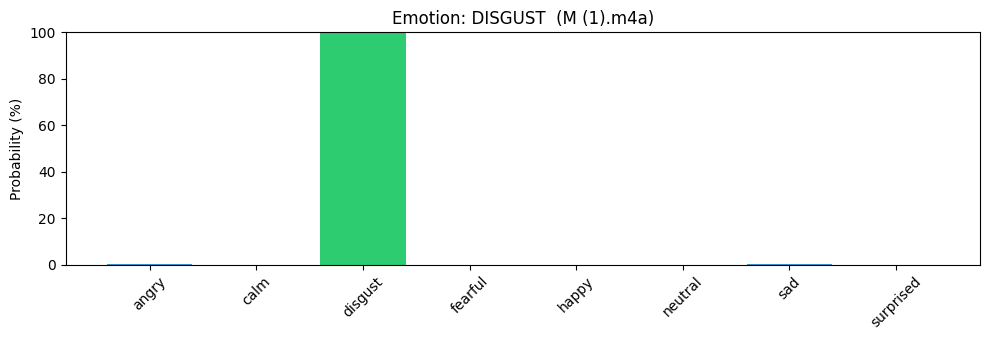


  File: Srikant (1).m4a
  Predicted: CALM (97.3%)
  →       calm:  97.3%  ██████████████████████████████████████
       disgust:   1.9%  
           sad:   0.5%  
       neutral:   0.2%  
         angry:   0.0%  
         happy:   0.0%  
     surprised:   0.0%  
       fearful:   0.0%  


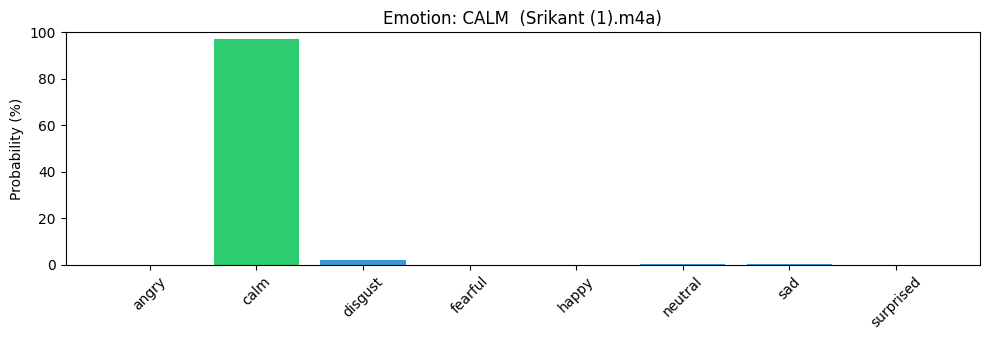

In [ ]:
# Predict on all recordings you uploaded
for filename in uploaded_audio.keys():
    predict_emotion(filename)